# 03 · Comparative evaluation

Baseline vs fine-tuned model vs ensemble, across two test sets and with business-oriented metrics.

**Systems** (a deliberate ladder: each rung adds exactly one component)

| System | Composition |
|---|---|
| `rules` | regex + checksum validators |
| `presidio` | Presidio + spaCy (`en_core_web_md`, `es_core_news_md`) |
| `baseline_rules_presidio` | the two above, fused |
| `finetuned_model` | fine-tuned multilingual DistilBERT |
| `ensemble` | baseline + model, with fusion and calibration |

**Test sets**

| Test set | What it measures |
|---|---|
| `ai4privacy` | held-out slice of the training distribution (isolated sentences) |
| `synthetic_documents` | complete documents from a different generator → *domain shift* |

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

RESULTS = Path('../results')
results = json.loads((RESULTS / 'metrics' / 'evaluation.json').read_text())
print(results['note'])

The ai4privacy corpus contains no card or bank-account numbers, so ['BANK_ACCOUNT', 'CREDIT_CARD'] are unreachable for the fine-tuned model by construction and are covered by the checksum-backed rule engine inside the ensemble.


## 1. Comparison table

`F1_exact` requires the span boundaries to match character for character. `F1_partial` accepts an
IoU ≥ 0.5 overlap. Both are reported because confusing *"the entity was detected but with a shifted
boundary"* with *"the entity was missed"* leads to opposite conclusions: the first is cosmetic for
redaction, the second is a leak.

In [2]:
df = pd.read_csv(RESULTS / 'metrics' / 'comparison.csv')
for ts in df.test_set.unique():
    print(f'\n=== {ts} ===')
    display(df[df.test_set == ts].drop(columns=['test_set','system_key']).reset_index(drop=True))


=== ai4privacy ===


,system,P_exact,R_exact,F1_exact,F1_partial,F1_macro,entity_leakage,over_redaction,docs_per_sec
0,Rules (regex + checksums),0.7556,0.2448,0.3698,0.3929,0.3847,0.7287,0.005325,4340.39
1,Presidio,0.3648,0.2357,0.2864,0.3222,0.3084,0.6299,0.038417,23.67
2,Baseline (rules + Presidio),0.4335,0.3218,0.3694,0.4132,0.4002,0.5489,0.040257,37.25
3,Fine-tuned model,0.9190,0.9226,0.9208,0.9516,0.8970,0.0625,0.003287,38.16
4,Ensemble (baseline + model),0.7327,0.9012,0.8083,0.8428,0.7586,0.0683,0.039706,21.54



=== synthetic_documents ===


,system,P_exact,R_exact,F1_exact,F1_partial,F1_macro,entity_leakage,over_redaction,docs_per_sec
0,Rules (regex + checksums),0.9368,0.5609,0.7017,0.7343,0.7314,0.4361,0.000240,1537.34
1,Presidio,0.5569,0.5722,0.5644,0.6086,0.5291,0.3048,0.045858,30.43
2,Baseline (rules + Presidio),0.6216,0.6857,0.6521,0.7120,0.7130,0.2448,0.045915,30.40
3,Fine-tuned model,0.5042,0.5787,0.5389,0.6506,0.5421,0.3148,0.035380,36.41
4,Ensemble (baseline + model),0.5989,0.8070,0.6875,0.7650,0.7884,0.1478,0.071115,19.00


## 2. The two metrics that decide whether this ships

Precision/recall answer *"is the model good?"*. They do not answer the two questions that actually
matter:

- **PII leakage** (`entity_leakage`): what share of real entities survived without being fully
  redacted. This is the metric with legal consequences.
- **Over-redaction** (`over_redaction`): what share of legitimate characters was destroyed. This is
  what makes the document useless to the business even when privacy is perfect.

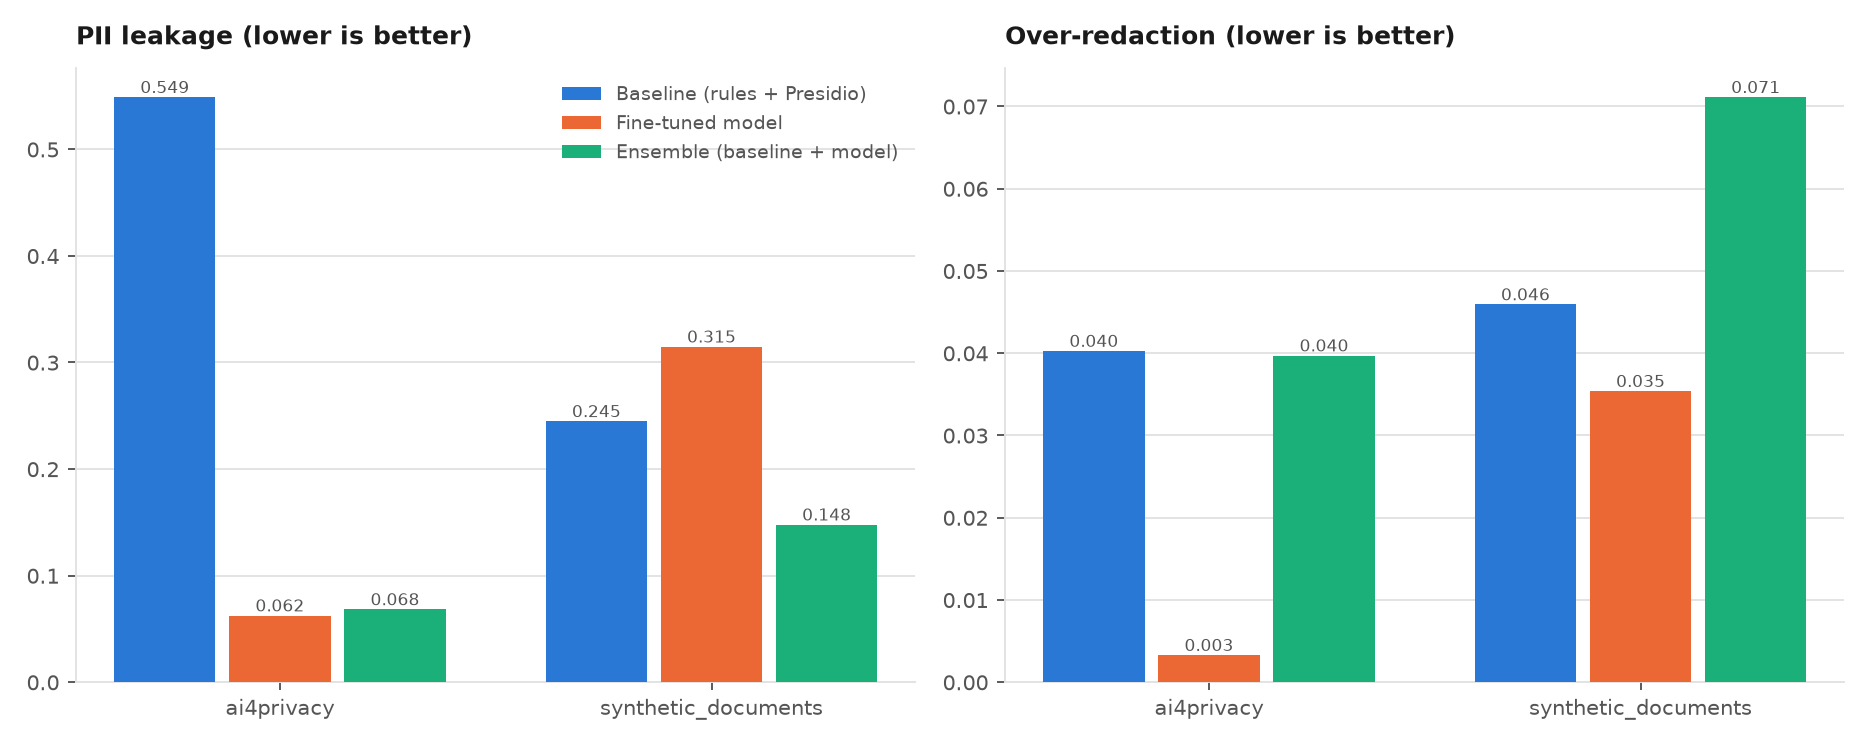

In [3]:
display(Image(filename=str(RESULTS / 'figures' / 'privacy_tradeoff.png')))

In [4]:
piv = df.pivot_table(index='system', columns='test_set',
                     values=['entity_leakage','over_redaction'])
display(piv)

entity_leakage                     over_redaction  \
test_set                        ai4privacy synthetic_documents     ai4privacy   
system                                                                          
Baseline (rules + Presidio)         0.5489              0.2448       0.040257   
Ensemble (baseline + model)         0.0683              0.1478       0.039706   
Fine-tuned model                    0.0625              0.3148       0.003287   
Presidio                            0.6299              0.3048       0.038417   
Rules (regex + checksums)           0.7287              0.4361       0.005325   

                                                 
test_set                    synthetic_documents  
system                                           
Baseline (rules + Presidio)            0.045915  
Ensemble (baseline + model)            0.071115  
Fine-tuned model                       0.035380  
Presidio                               0.045858  
Rules (regex + checksums)              0.000240

## 3. Where each approach wins

The per-type comparison is the most informative result in the project: **there is no single winner**.

- **Rules** dominate on structured identifiers: an IBAN that passes mod-97 or a card that passes
  Luhn is not an estimate, it is a proof.
- The **model** dominates on free text — names, addresses — where a regex can only fire on an
  honorific or an explicit field label.
- The **ensemble** exists because those two strengths are complementary, not redundant.

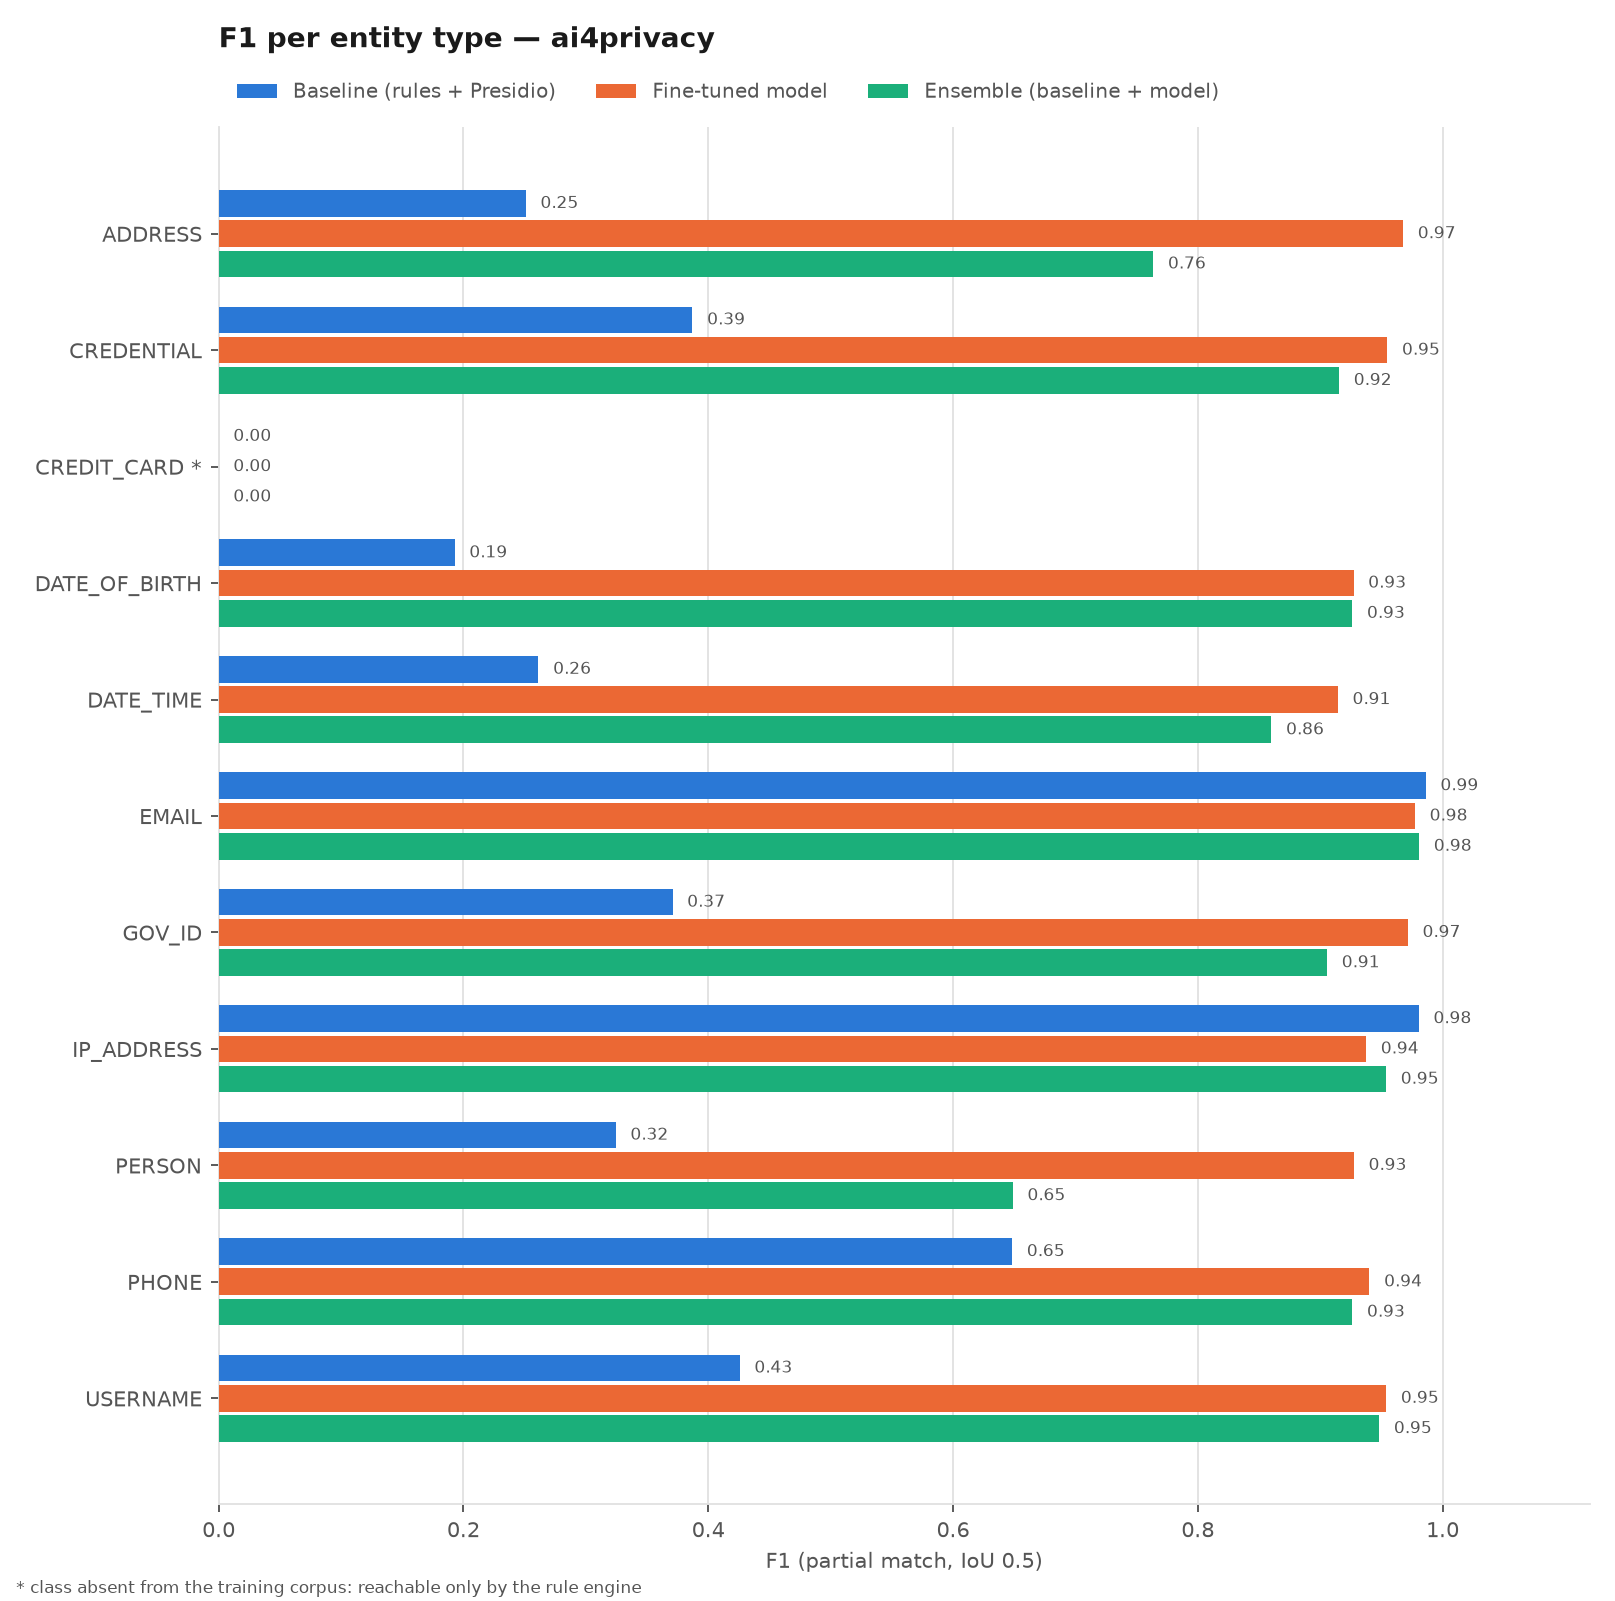

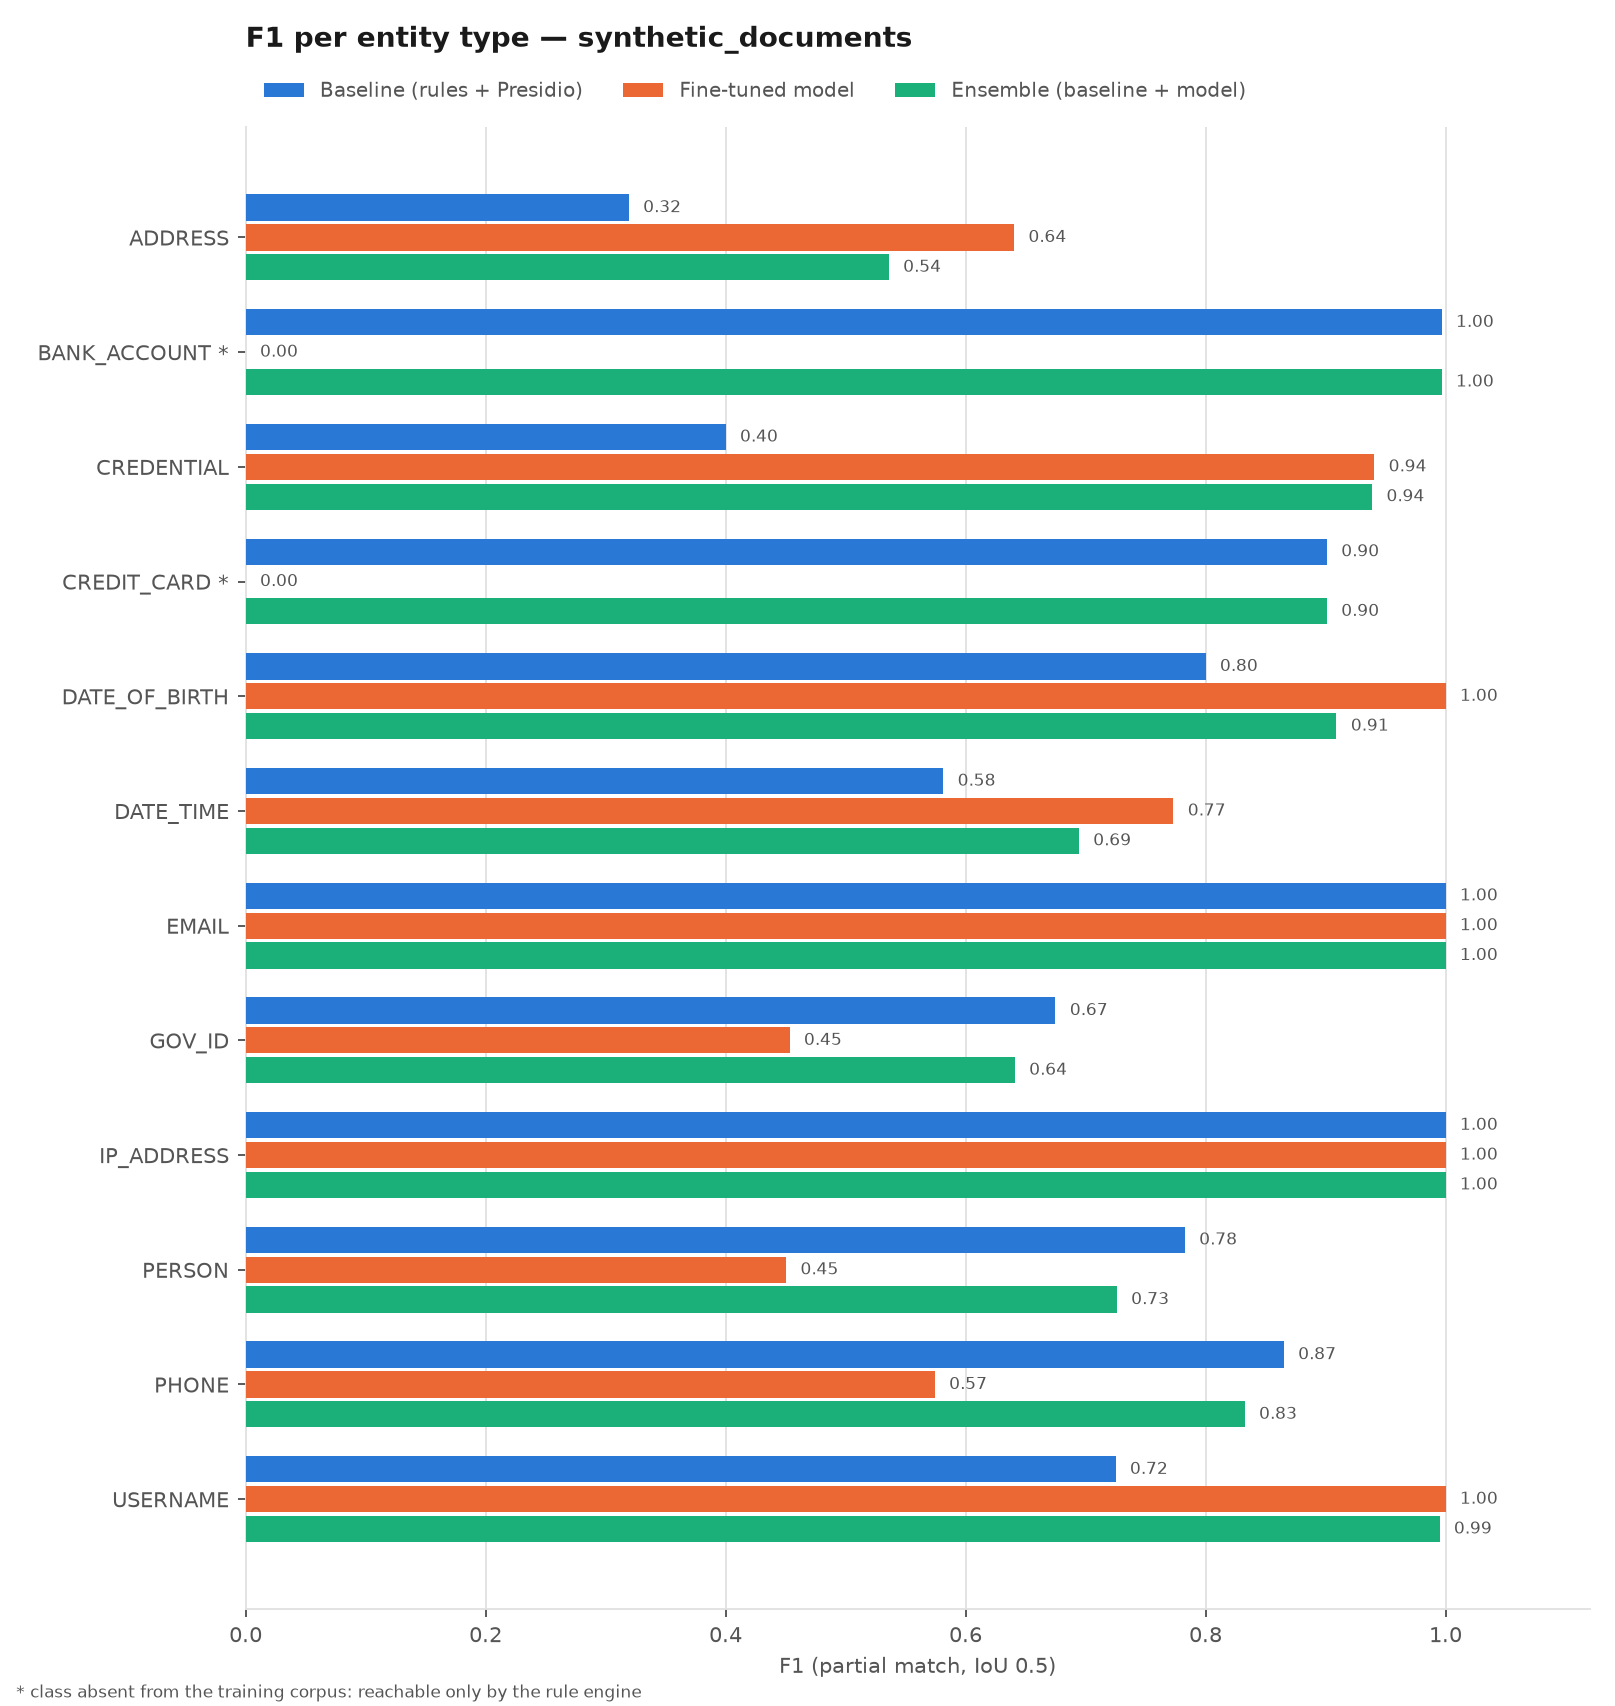

In [5]:
for ts in results['test_sets']:
    display(Image(filename=str(RESULTS / 'figures' / f'f1_by_type_{ts}.png')))

In [6]:
ood = results['test_sets']['synthetic_documents']['systems']
comp = pd.DataFrame({
    name: {t: v['f1'] for t, v in ood[name]['partial']['by_type'].items()}
    for name in ['baseline_rules_presidio','finetuned_model','ensemble'] if name in ood
}).fillna(0).round(4)
comp['best'] = comp.idxmax(axis=1)
comp.sort_index()

,baseline_rules_presidio,finetuned_model,ensemble,best
ADDRESS,0.3193,0.6404,0.5360,finetuned_model
BANK_ACCOUNT,0.9967,0.0000,0.9967,baseline_rules_presidio
CREDENTIAL,0.4000,0.9406,0.9388,finetuned_model
CREDIT_CARD,0.9011,0.0000,0.9011,baseline_rules_presidio
DATE_OF_BIRTH,0.8000,1.0000,0.9091,finetuned_model
DATE_TIME,0.5814,0.7732,0.6944,finetuned_model
EMAIL,1.0000,1.0000,1.0000,baseline_rules_presidio
GOV_ID,0.6749,0.4533,0.6410,baseline_rules_presidio
IP_ADDRESS,1.0000,1.0000,1.0000,baseline_rules_presidio
PERSON,0.7827,0.4504,0.7260,baseline_rules_presidio


## 4. Confidence calibration

A detector's raw score is not a probability: a rule that says 0.9 and a model that says 0.9 are not
right equally often. The review-queue thresholds only mean something once that score is mapped onto
observed precision.

**Platt scaling** is used (not plain temperature scaling) because the noisy-OR fusion introduces a
systematic bias as well as a sharpness error, and a single temperature cannot correct a bias.

predictions evaluated : 2,613
empirical precision   : 0.7666
ECE raw               : 0.1928
ECE global Platt      : 0.1683
ECE grouped Platt     : 0.0508


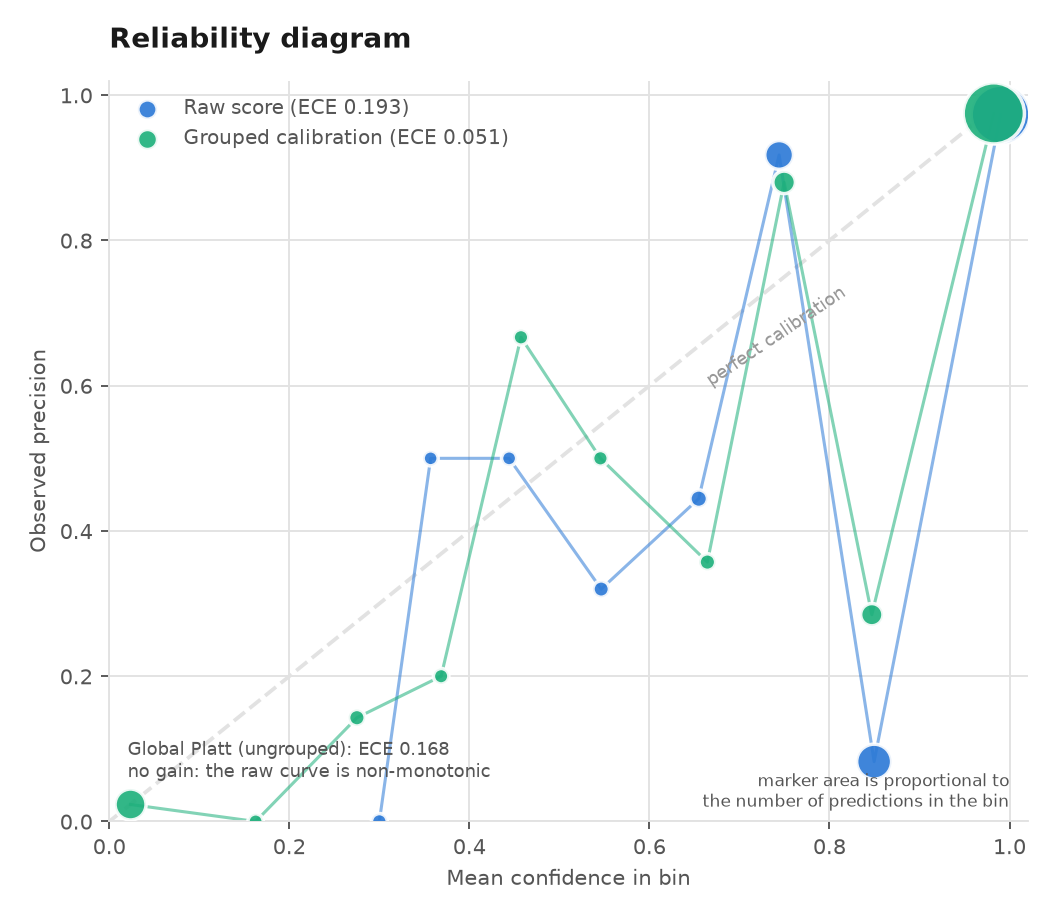

In [7]:
cal = json.loads((RESULTS / 'metrics' / 'calibration.json').read_text())
print(f"predictions evaluated : {cal['n_predictions']:,}")
print(f"empirical precision   : {cal['empirical_precision']:.4f}")
print(f"ECE raw               : {cal['ece_before']:.4f}")
print(f"ECE global Platt      : {cal['ece_after_global_platt']:.4f}")
print(f"ECE grouped Platt     : {cal['ece_after']:.4f}")
display(Image(filename=str(RESULTS / 'figures' / 'reliability_diagram.png')))

## 5. The review queue

Default thresholds: ≥0.90 automatic redaction, [0.50, 0.90) human review, <0.50 discarded (but
logged). On top of that, business rules that force review regardless of score:

- a **high-risk** entity (card, account, identity document, credential) below 0.95;
- a **type conflict** between detectors over the same span;
- a **failing checksum**;
- a span seen by **a single detector** with confidence below 0.97.

An important detail: whatever lands in the queue **is redacted anyway**. A reviewer can always put a
false positive back; a leak that has already shipped cannot be recalled.

{
  "n_documents": 120,
  "decisions": {
    "auto_redact": 596,
    "review": 764,
    "discard": 271
  },
  "review_rate": 0.4684,
  "auto_rate": 0.3654,
  "verbatim_leaks_after_redaction": 0,
  "queue_status": {
    "pending": 764
  }
}


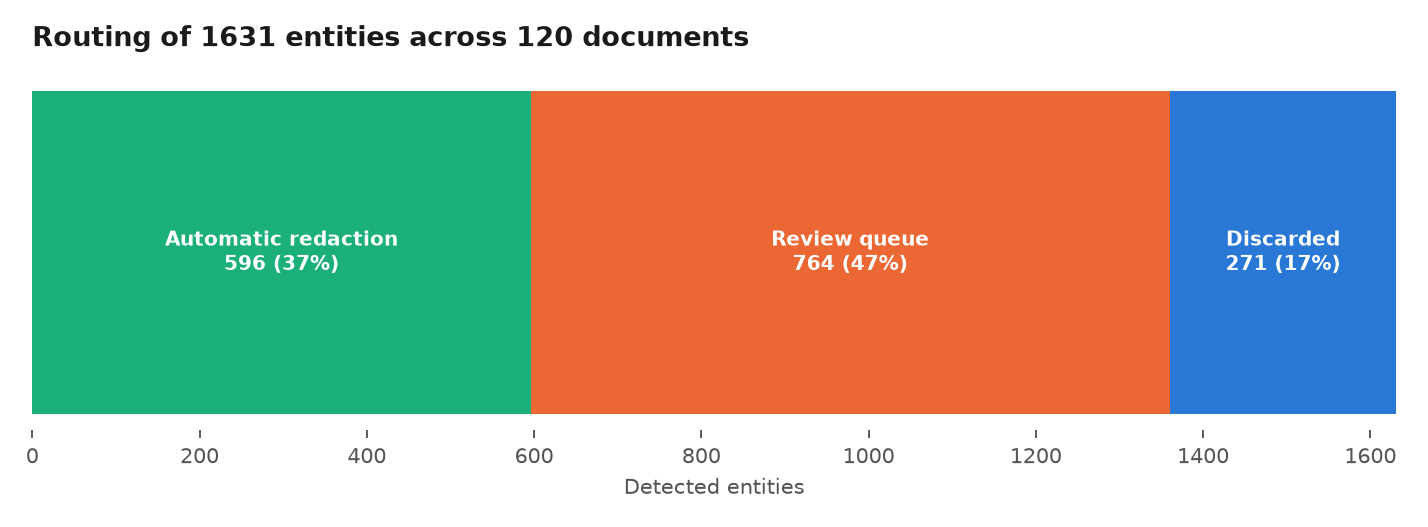

In [8]:
queue = json.loads((RESULTS / 'metrics' / 'queue_stats.json').read_text())
print(json.dumps(queue, ensure_ascii=False, indent=2))
display(Image(filename=str(RESULTS / 'figures' / 'review_queue.png')))

## 6. End-to-end example

In [9]:
ejemplos = sorted((RESULTS / 'examples').glob('*.input.txt'))
muestra = next((p for p in ejemplos if 'invoice_es' in p.name), ejemplos[0])
original = muestra.read_text()
redactado = Path(str(muestra).replace('.input.', '.redacted.')).read_text()
auditoria = json.loads(Path(str(muestra).replace('.input.txt', '.audit.json')).read_text())

print('=== ORIGINAL ===');  print(original)
print('=== REDACTED ==='); print(redactado)
print('=== ENTITIES ===')
display(pd.DataFrame([
    {'type': e['type'], 'value': e['text'], 'score': round(e['score'], 3),
     'decision': e['decision'], 'detectors': ', '.join(e['metadata'].get('detectors', []))}
    for e in auditoria['entities']
]))
print('verified leaks after redaction:', auditoria['leaks'])

=== ORIGINAL ===
FACTURA N.º 2025-1791
Cabán-Jimínez
Fecha de emisión: 16/01/2026

DATOS DEL CLIENTE
Nombre: Aida Corona
NIF/DNI: 61858910658
Domicilio: Andador Sur Garica 909 Edif. 960 , Depto. 308, Vieja Maldivas 81948
Teléfono: 908.301.6613   Email: acorona@arriaga.com

Concepto: Servicios de consultoría (ref. ORD-175954, SKU-78-2542)
Base imponible: 9668,17 EUR   IVA (10%)

FORMA DE PAGO
Domiciliación en cuenta GB84FDSS3518190937865
Tarjeta asociada: 38543231948758

=== REDACTED ===
FACTURA N.º 2025-1791
[DIRECCION]: [FECHA]

DATOS DEL CLIENTE
Nombre: [NOMBRE]
NIF/DNI: [IDENTIFICACION]
Domicilio: Andador [DIRECCION]. [DIRECCION] , [DIRECCION]. 308, [DIRECCION] Maldivas [DIRECCION]
Teléfono: [TELEFONO]   Email: [EMAIL]

Concepto: Servicios de consultoría (ref. ORD-175954, [IDENTIFICACION])
Base imponible: [DIRECCION],17 EUR   IVA (10%)

FORMA DE PAGO
Domiciliación en cuenta [CUENTA_BANCARIA]
Tarjeta asociada: [TARJETA]

=== ENTITIES ===


,type,value,score,decision,detectors
0,ADDRESS,Cabán-Jimínez\nFecha de emisión,0.755,review,"model, presidio"
1,DATE_TIME,16/01/2026,0.983,auto_redact,"model, presidio, rules"
2,PERSON,Aida Corona,0.963,auto_redact,"model, presidio, rules"
3,GOV_ID,61858910658,0.967,review,"model, presidio"
4,ADDRESS,Sur Garica 909 Edif,0.850,review,"model, presidio"
5,ADDRESS,960,0.878,review,model
6,ADDRESS,Depto,0.868,review,"model, presidio"
7,ADDRESS,Vieja,0.840,review,"model, presidio"
8,ADDRESS,81948,0.964,review,model
9,ADDRESS,Teléfono,0.035,discard,presidio


verified leaks after redaction: []


## Conclusions

1. **No system wins at everything.** The rules/model split by entity type is the central finding, and
   it is what justifies the hybrid architecture instead of "train a bigger model".
2. **Domain shift is real.** The drop between the in-distribution test set and complete documents is
   the number to look at before promising anything in production.
3. **Calibration turns a score into an operational decision.** Without it, the queue thresholds are
   arbitrary numbers.
4. **Leakage and over-redaction are the real dashboard**, not F1.